# Vertex Cover Algorithm Comparison Plots

Simple visualizations comparing vertex cover algorithms across different graph models.

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.approximation import min_weighted_vertex_cover
from algorithms import greedy_support, dijkstra_approx, cover_local_search
from benchmark import maximum_matching_lower_bound

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
def draw_comparison_figure(G, title):
    """Draw a 2x2 subplot comparing different vertex cover algorithms."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'{title} (n={G.number_of_nodes()}, m={G.number_of_edges()})', fontsize=16)
    
    # Calculate positions once for consistency
    pos = nx.spring_layout(G, seed=42)
    
    lb = maximum_matching_lower_bound(G)

    # Algorithm configurations
    algorithms = [
        ("NetworkX Approx", lambda g: set(min_weighted_vertex_cover(g))),
        ("Greedy Support", greedy_support),
        ("Dijkstra Approx", lambda g: dijkstra_approx(g, start_node=next(iter(g.nodes())))),
        ("Local Search", lambda g: cover_local_search(g, k=int(lb * 1.4) + 2 if lb > 0 else 5, max_iterations=5000))
    ]
    
    for idx, (name, algo_func) in enumerate(algorithms):
        ax = axes[idx // 2, idx % 2]
        
        try:
            cover = algo_func(G)
            cover_size = len(cover)
            
            # Draw graph with cover highlighted
            node_colors = ['red' if node in cover else 'lightblue' for node in G.nodes()]
            nx.draw(G, pos, ax=ax, node_color=node_colors, node_size=100, 
                   with_labels=False, edge_color='gray', alpha=0.7)
            
            ax.set_title(f'{name}\nCover Size: {cover_size}')
            
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:30]}', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{name}\nError')
    
    plt.tight_layout()
    return fig

Generated G(n,p) graph: 50 nodes, 120 edges


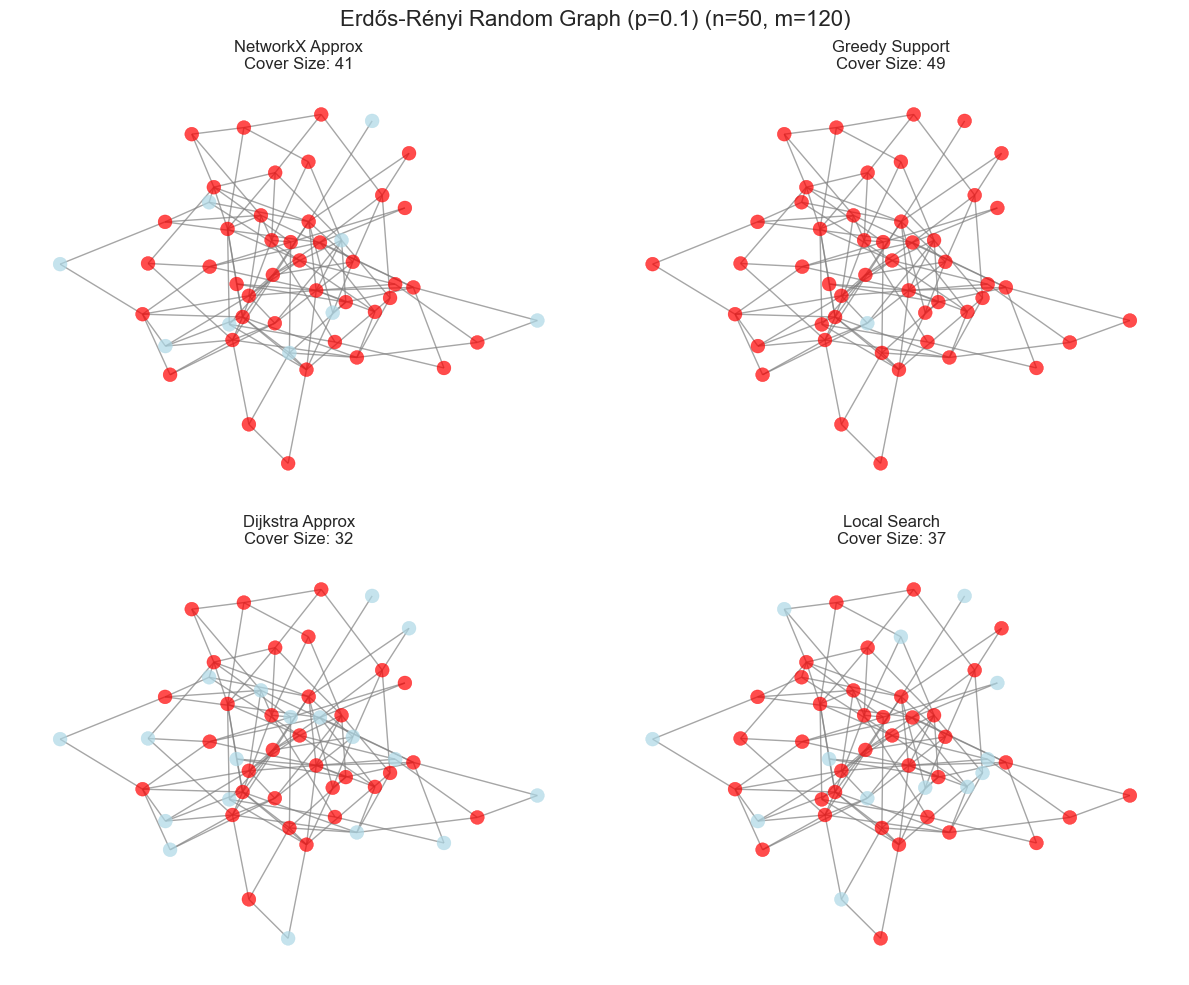

In [6]:
G_gnp = nx.gnp_random_graph(n=50, p=0.1, seed=100)
print(f"Generated G(n,p) graph: {G_gnp.number_of_nodes()} nodes, {G_gnp.number_of_edges()} edges")

fig1 = draw_comparison_figure(G_gnp, "Erdős-Rényi Random Graph (p=0.1)")
plt.show()

Generated Barabási-Albert graph: 50 nodes, 141 edges


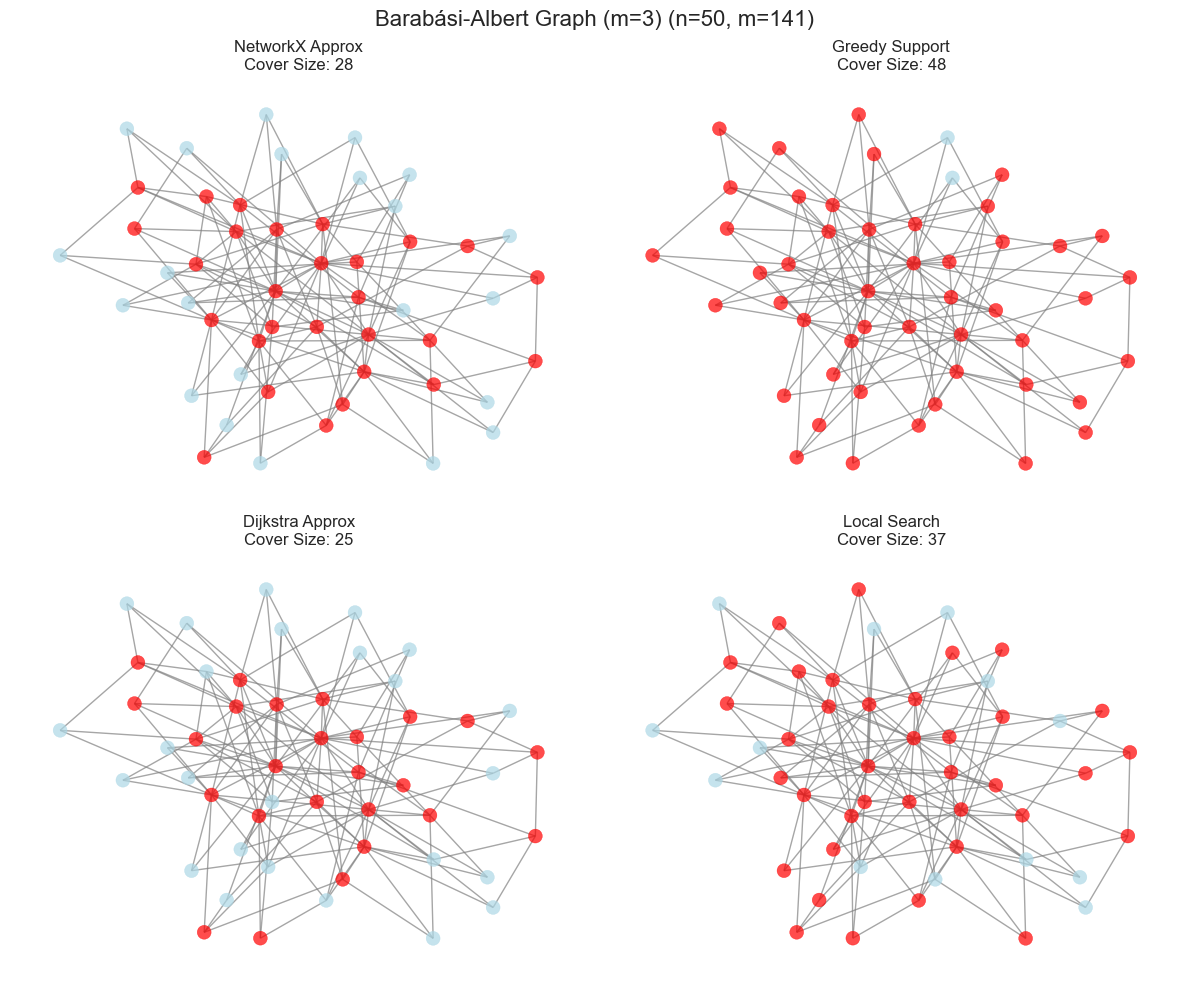

In [7]:
# Barabási-Albert Preferential Attachment Graph
G_ba = nx.barabasi_albert_graph(n=50, m=3, seed=200)
print(f"Generated Barabási-Albert graph: {G_ba.number_of_nodes()} nodes, {G_ba.number_of_edges()} edges")

fig2 = draw_comparison_figure(G_ba, "Barabási-Albert Graph (m=3)")
plt.show()

Generated Random Regular graph: 50 nodes, 150 edges


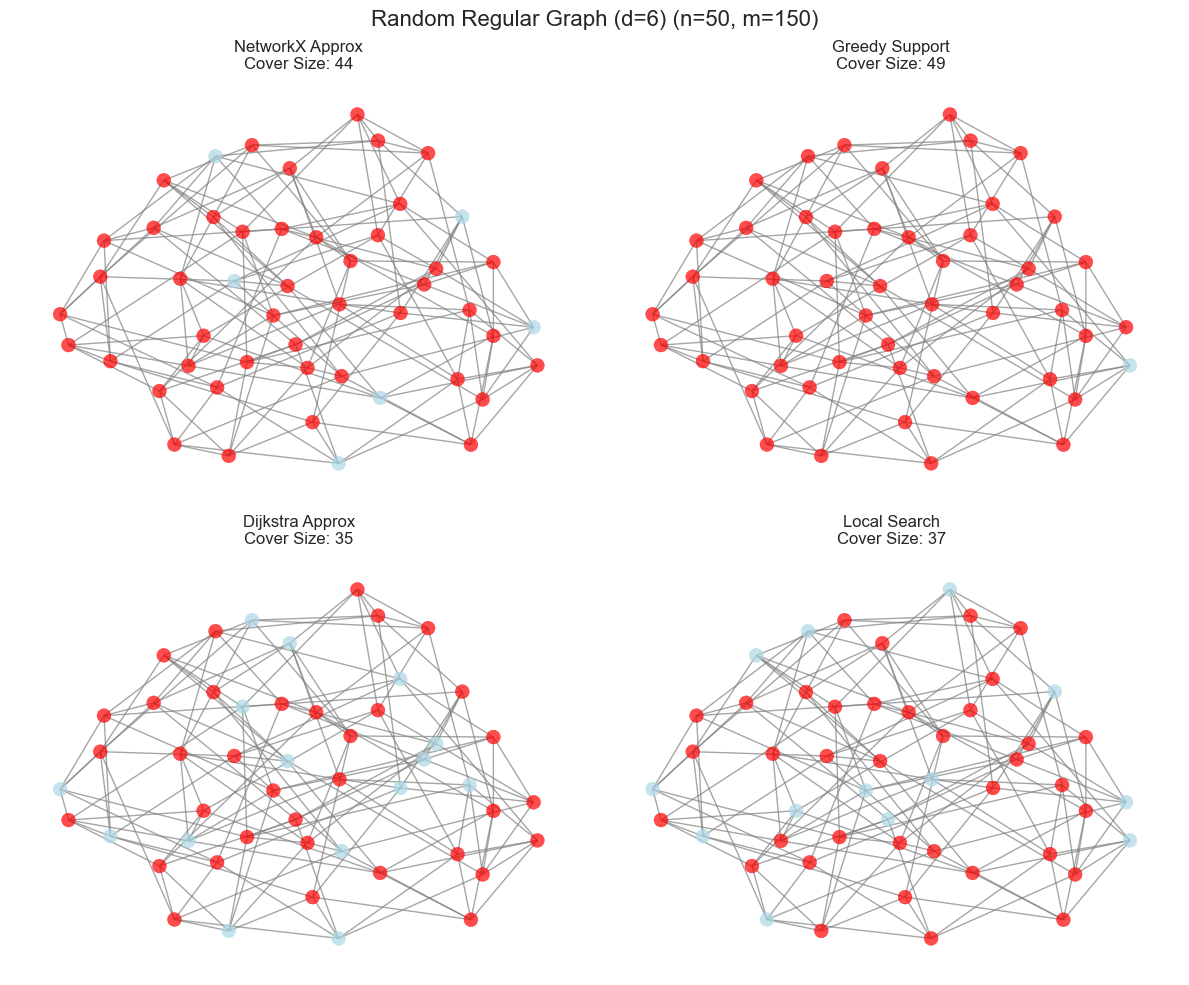

In [8]:
# Random Regular Graph
G_reg = nx.random_regular_graph(d=6, n=50, seed=300)
print(f"Generated Random Regular graph: {G_reg.number_of_nodes()} nodes, {G_reg.number_of_edges()} edges")

fig3 = draw_comparison_figure(G_reg, "Random Regular Graph (d=6)")
plt.show()

Generated Watts-Strogatz graph: 50 nodes, 200 edges


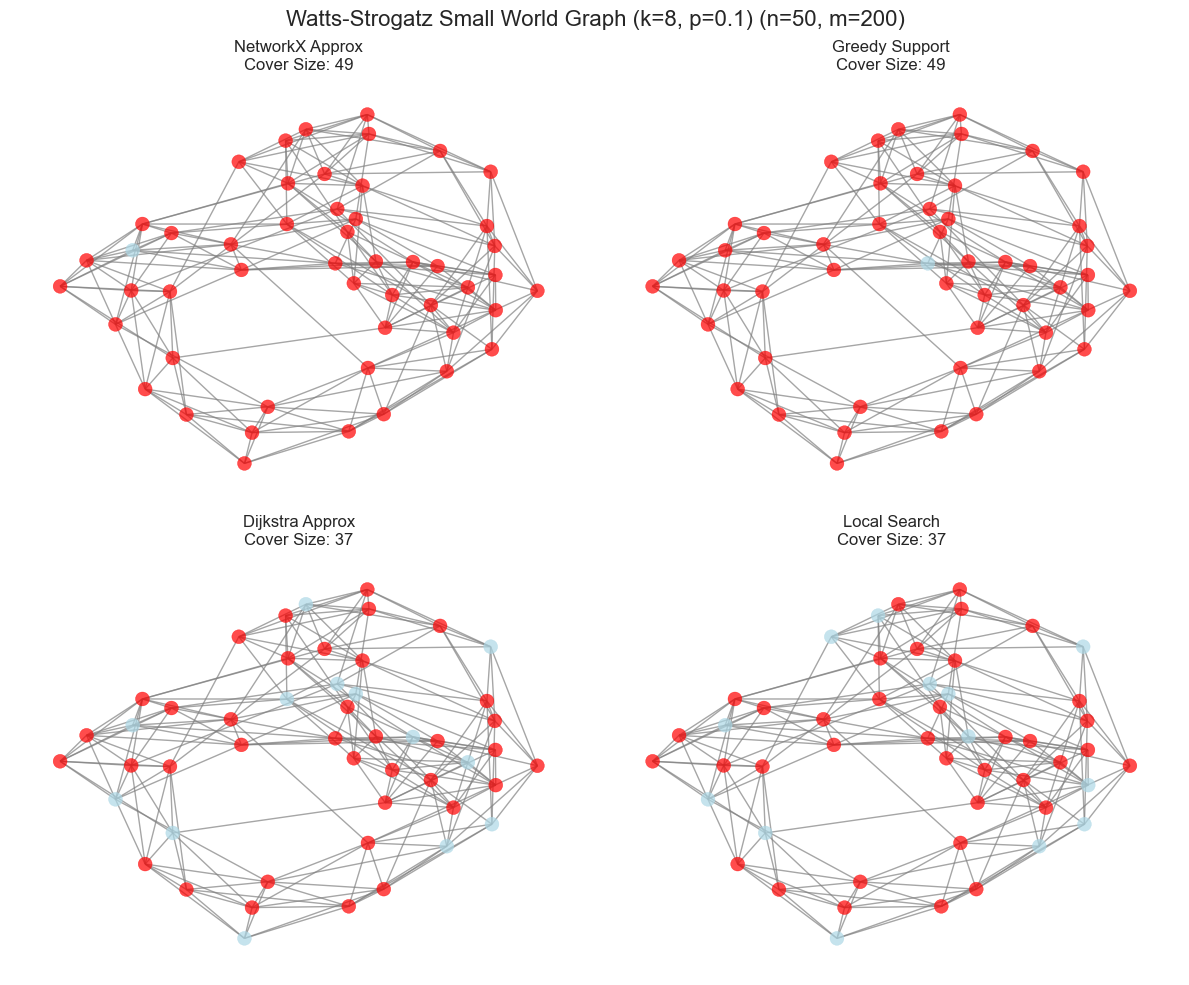

In [9]:
# Watts-Strogatz Small World Graph
G_ws = nx.watts_strogatz_graph(n=50, k=8, p=0.1, seed=400)
print(f"Generated Watts-Strogatz graph: {G_ws.number_of_nodes()} nodes, {G_ws.number_of_edges()} edges")

fig4 = draw_comparison_figure(G_ws, "Watts-Strogatz Small World Graph (k=8, p=0.1)")
plt.show()